# HDT 4: Regresión Logística y Métricas

**Ciencia de Datos, Sección A** · Asignada: jueves 17 de septiembre · **Entrega: martes 22 de septiembre, 23:59**

**Nombre:** Juan Pablo Madriz

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semilla fija y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Una empresa de internet residencial quiere saber qué clientes van a cancelar. Historial de 1,200 clientes: `mensualidad` (quetzales al mes), `meses` (antigüedad como cliente), `reclamos` (en el último año) y `cancelo` (1 = canceló el servicio). Es el mismo tipo de problema que la mora de la sesión 14, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
rng = np.random.default_rng(9)
n = 1200
mensualidad = rng.normal(350, 90, n).clip(150, 700).round(0)
meses = rng.integers(1, 61, n)
reclamos = np.minimum(rng.poisson(0.8, n), 6)

riesgo = -1.1 + 0.006 * (mensualidad - 350) - 0.06 * meses + 0.9 * reclamos
cancelo = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"mensualidad": mensualidad, "meses": meses,
                   "reclamos": reclamos, "cancelo": cancelo})
print("clientes:", len(df), "| fracción que canceló:", df["cancelo"].mean().round(3))
df.head()

clientes: 1200 | fracción que canceló: 0.169


,mensualidad,meses,reclamos,cancelo
0,278.0,48,0,0
1,372.0,46,0,0
2,201.0,7,0,0
3,409.0,24,2,0
4,453.0,48,3,0


## Parte A · El modelo (0.5 pt)

Regresión logística como en la sesión 14: una suma con pesos que la sigmoide convierte en una probabilidad entre 0 y 1.

### Ejercicio 1 (0.15): entrenar y leer los pesos

Entrenar el pipeline de clase (StandardScaler + LogisticRegression) sobre el split dado. Extraer el punto de partida `b` y los tres `pesos`, e imprimirlos con el nombre de su columna. Responder en un comentario: ¿qué columna protege más contra la cancelación?

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columnas = ["mensualidad", "meses", "reclamos"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["cancelo"], test_size=0.3, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)
b = modelo[1].intercept_[0]      # intercept de la regresión
pesos = modelo[1].coef_[0]       # los tres coeficientes, en el orden de `columnas`

print(f"b (punto de partida) = {b:6.2f}")
for columna, peso in zip(columnas, pesos):
    print(f"  {columna:12s} peso = {peso:+.2f}")

# Respuesta: la que más protege contra la cancelación es `meses` (antigüedad).
# Es el único peso negativo (-1.35) y además el de mayor magnitud: cada desviación
# estándar extra de antigüedad es lo que más empuja la probabilidad hacia abajo.
# `mensualidad` (+0.64) y `reclamos` (+0.62) empujan en sentido contrario.

# Verificación (descomentar):
assert round(b, 2) == -2.29
assert [round(w, 2) for w in pesos] == [0.64, -1.35, 0.62]
print("\nverificación OK")

b (punto de partida) =  -2.29
  mensualidad  peso = +0.64
  meses        peso = -1.35
  reclamos     peso = +0.62

verificación OK


### Ejercicio 2 (0.20): un cliente, a mano

Cliente nuevo: paga Q380, lleva 4 meses, puso 2 reclamos. Calcular su probabilidad de cancelar sin `predict_proba`: (a) escalar cada valor con `escalador.mean_` y `escalador.scale_`, (b) armar la suma `b + w1 * x1 + w2 * x2 + w3 * x3`, (c) pasarla por la sigmoide. Luego comparar contra `modelo.predict_proba`: deben coincidir.

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

cliente = pd.DataFrame({"mensualidad": [380.0], "meses": [4], "reclamos": [2]})

# el escalador es modelo[0]; sus medias y desviaciones: .mean_ y .scale_
escalador = modelo[0]
x = (cliente[columnas].to_numpy()[0] - escalador.mean_) / escalador.scale_

z = b + pesos[0] * x[0] + pesos[1] * x[1] + pesos[2] * x[2]
p_mano = sigmoide(z)
p_sklearn = modelo.predict_proba(cliente)[0, 1]

for columna, crudo, escalado in zip(columnas, cliente.to_numpy()[0], x):
    print(f"  {columna:12s} {crudo:6.1f} -> escalado {escalado:+.3f}")
print(f"\nz = {z:.3f}")
print(f"p a mano   = {p_mano:.3f}")
print(f"p sklearn  = {p_sklearn:.3f}")

# Verificación (descomentar):
assert round(p_mano, 3) == round(p_sklearn, 3) == 0.721
print("verificación OK")

  mensualidad   380.0 -> escalado +0.335
  meses           4.0 -> escalado -1.596
  reclamos        2.0 -> escalado +1.393

z = 0.949
p a mano   = 0.721
p sklearn  = 0.721
verificación OK


### Ejercicio 3 (0.15): equivocarse con confianza cuesta caro

El castigo de una predicción es `-log(p asignada a lo que realmente pasó)`. (a) Calcular el castigo para un cliente que sí canceló al que el modelo le dijo 0.99, 0.9, 0.5, 0.1 y 0.01. (b) Con `log_loss`, el castigo promedio del modelo en test contra el de un modelo tibio que le dice 0.5 a todo el mundo.

In [5]:
from sklearn.metrics import log_loss

p_dijo = np.array([0.99, 0.9, 0.5, 0.1, 0.01])
castigos = -np.log(p_dijo)

print("cliente que SÍ canceló:")
for p, castigo in zip(p_dijo, castigos):
    print(f"  el modelo le dijo {p:4.2f} -> castigo = {castigo:.2f}")

prob = modelo.predict_proba(X_test)[:, 1]      # probabilidades del test
castigo_modelo = log_loss(y_test, prob)
castigo_tibio = log_loss(y_test, np.full(len(y_test), 0.5))

print(f"\ncastigo promedio del modelo = {castigo_modelo:.3f}")
print(f"castigo promedio del tibio  = {castigo_tibio:.3f}")

# Verificación (descomentar):
assert round(castigos[-1], 1) == 4.6
assert round(castigo_modelo, 3) == 0.347 and round(castigo_tibio, 3) == 0.693
print("verificación OK")

cliente que SÍ canceló:
  el modelo le dijo 0.99 -> castigo = 0.01
  el modelo le dijo 0.90 -> castigo = 0.11
  el modelo le dijo 0.50 -> castigo = 0.69
  el modelo le dijo 0.10 -> castigo = 2.30
  el modelo le dijo 0.01 -> castigo = 4.61

castigo promedio del modelo = 0.347
castigo promedio del tibio  = 0.693
verificación OK


## Parte B · Métricas como conteos (0.5 pt)

Solo el 17% de los clientes cancela. Con clases desbalanceadas, contar aciertos engaña; contar por tipo de acierto y de error, no.

### Ejercicio 4 (0.15): el modelo perezoso

(a) La accuracy de un modelo perezoso que dice "nadie cancela". (b) La accuracy del modelo real con umbral 0.5. Ver qué tan poca ventaja aparenta tener el modelo cuando se mide con la métrica equivocada.

In [6]:
y_real = y_test.to_numpy()
pred = (prob >= 0.5).astype(int)      # predicciones con umbral 0.5

acc_perezoso = (y_real == 0).mean()   # fracción de y_test que es 0
acc_modelo = (pred == y_real).mean()

print(f"accuracy del perezoso ('nadie cancela') = {acc_perezoso:.3f}")
print(f"accuracy del modelo (umbral 0.5)        = {acc_modelo:.3f}")
print(f"ventaja aparente                        = {acc_modelo - acc_perezoso:.3f}")

# Verificación (descomentar):
assert round(acc_perezoso, 3) == 0.833
assert round(acc_modelo, 3) == 0.869
print("verificación OK")

accuracy del perezoso ('nadie cancela') = 0.833
accuracy del modelo (umbral 0.5)        = 0.869
ventaja aparente                        = 0.036
verificación OK


### Ejercicio 5 (0.20): los cuatro conteos

Con umbral 0.5, calcular los cuatro conteos y armar la tabla 2 x 2 como en clase (filas: canceló / se quedó; columnas: el modelo dijo cancela / dijo se queda).

In [7]:
TP = int(((pred == 1) & (y_real == 1)).sum())   # dijo cancela y canceló
FP = int(((pred == 1) & (y_real == 0)).sum())   # dijo cancela y se quedó: llamada desperdiciada
FN = int(((pred == 0) & (y_real == 1)).sum())   # dijo se queda y canceló: cliente perdido sin aviso
TN = int(((pred == 0) & (y_real == 0)).sum())   # dijo se queda y se quedó

tabla = pd.DataFrame([[TP, FN], [FP, TN]],
                     index=["canceló", "se quedó"],
                     columns=["dijo cancela", "dijo se queda"])
print(tabla)

# Verificación (descomentar):
assert [TP, FP, FN, TN] == [22, 9, 38, 291]
assert TP + FP + FN + TN == len(y_test)
print("\nverificación OK")

          dijo cancela  dijo se queda
canceló             22             38
se quedó             9            291

verificación OK


### Ejercicio 6 (0.15): las dos preguntas del negocio

Desde los conteos, sin sklearn: precision (de las alertas, ¿cuántas eran canceladores de verdad?) y recall (de los que cancelaron, ¿a cuántos alcanzó a avisar el modelo?). Imprimir las dos frases completas con sus números, como en la sesión 14.

In [8]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"alertas: {TP + FP}, de ellas canceladores: {TP}  -> precision = {precision:.2f}")
print(f"canceladores reales: {TP + FN}, avisados: {TP}   -> recall = {recall:.2f}")

# Verificación (descomentar):
assert round(precision, 2) == 0.71
assert round(recall, 2) == 0.37
print("verificación OK")

alertas: 31, de ellas canceladores: 22  -> precision = 0.71
canceladores reales: 60, avisados: 22   -> recall = 0.37
verificación OK


## Parte C · Umbral, AUC y calibración (0.8 pt)

El 0.5 es un default, no una decisión. Y dos preguntas más profundas que cualquier umbral: ¿el modelo ordena bien?, ¿dice la verdad?

### Ejercicio 7 (0.20): mover el umbral

Para cada umbral en [0.2, 0.35, 0.5, 0.65]: recalcular predicciones, contar alertas, precision y recall, imprimir la línea y guardar el número de alertas en `alertas_por_umbral`. Esta tabla es el insumo de la parte D.

In [9]:
alertas_por_umbral = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral).astype(int)
    tp = int(((pred_u == 1) & (y_real == 1)).sum())
    fp = int(((pred_u == 1) & (y_real == 0)).sum())
    fn = int(((pred_u == 0) & (y_real == 1)).sum())

    alertas = tp + fp
    precision_u = tp / alertas if alertas else float("nan")
    recall_u = tp / (tp + fn)
    alertas_por_umbral.append(alertas)

    print(f"umbral {umbral:4.2f} | alertas {alertas:3d} | precision {precision_u:.2f} "
          f"| recall {recall_u:.2f} | perdidos sin aviso {fn:2d}")

# Verificación (descomentar):
assert alertas_por_umbral == [116, 63, 31, 12]
print("\nverificación OK")

umbral 0.20 | alertas 116 | precision 0.37 | recall 0.72 | perdidos sin aviso 17
umbral 0.35 | alertas  63 | precision 0.51 | recall 0.53 | perdidos sin aviso 28
umbral 0.50 | alertas  31 | precision 0.71 | recall 0.37 | perdidos sin aviso 38
umbral 0.65 | alertas  12 | precision 0.67 | recall 0.13 | perdidos sin aviso 52

verificación OK


### Ejercicio 8 (0.20): la curva completa

La misma idea, continua: para umbrales de 0.05 a 0.90 en pasos de 0.05, graficar precision (AZUL) y recall (ROJO) contra el umbral, con `eje_limpio`, leyenda y una línea vertical punteada en 0.5. Un vistazo a la figura debe bastar para ver el intercambio.

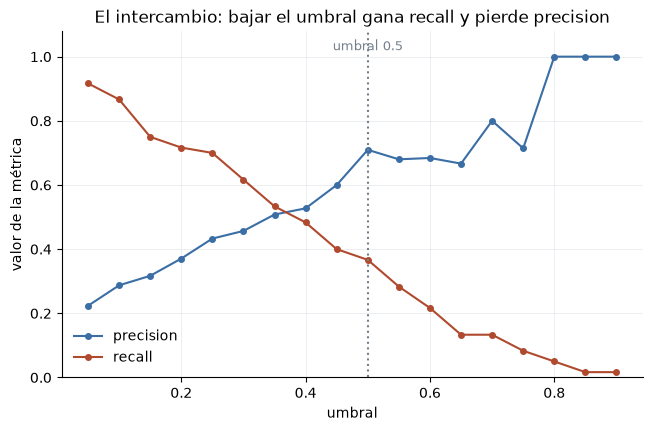

verificación OK


In [10]:
umbrales = np.arange(0.05, 0.91, 0.05)
precisiones = []
recalls = []

for umbral in umbrales:
    pred_u = (prob >= umbral).astype(int)
    tp = int(((pred_u == 1) & (y_real == 1)).sum())
    fp = int(((pred_u == 1) & (y_real == 0)).sum())
    fn = int(((pred_u == 0) & (y_real == 1)).sum())
    precisiones.append(tp / (tp + fp) if (tp + fp) else float("nan"))
    recalls.append(tp / (tp + fn))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(umbrales, precisiones, color=AZUL, marker="o", ms=4, label="precision")
ax.plot(umbrales, recalls, color=ROJO, marker="o", ms=4, label="recall")
ax.axvline(0.5, color=GRIS, ls=":", lw=1.5)
ax.annotate("umbral 0.5", xy=(0.5, 1.02), color=GRIS, ha="center", fontsize=9)
eje_limpio(ax)
ax.set_xlabel("umbral")
ax.set_ylabel("valor de la métrica")
ax.set_title("El intercambio: bajar el umbral gana recall y pierde precision")
ax.set_ylim(0, 1.08)
ax.legend(frameon=False)
plt.show()

# Verificación (descomentar):
assert len(precisiones) == len(recalls) == len(umbrales) == 18
print("verificación OK")

### Ejercicio 9 (0.20): AUC por pares

AUC sin fórmula, como en la sesión: tomar 5,000 canceladores al azar y 5,000 no canceladores al azar (con `rng_auc.choice`, en ese orden), y medir en qué fracción de los pares el cancelador recibió mayor probabilidad. Comparar contra `roc_auc_score`.

In [11]:
from sklearn.metrics import roc_auc_score

rng_auc = np.random.default_rng(7)

pos = prob[y_real == 1]   # probabilidades de los que cancelaron
neg = prob[y_real == 0]   # probabilidades de los que se quedaron
# luego, exactamente en este orden:
p_azar = rng_auc.choice(pos, 5000)
n_azar = rng_auc.choice(neg, 5000)

auc_pares = float((p_azar > n_azar).mean())   # pares donde el cancelador tuvo mayor probabilidad
auc_sklearn = roc_auc_score(y_test, prob)

print(f"AUC por pares al azar = {auc_pares:.3f}")
print(f"AUC de sklearn        = {auc_sklearn:.3f}")

# Verificación (descomentar):
assert round(auc_pares, 3) == 0.821
assert round(auc_sklearn, 3) == 0.822
print("verificación OK")

AUC por pares al azar = 0.821
AUC de sklearn        = 0.822
verificación OK


### Ejercicio 10 (0.20): ¿dice la verdad?

Agrupar las probabilidades del test en cajones con `pd.cut` (bordes [0, 0.2, 0.4, 0.6, 0.8, 1.0]) y construir la tabla de calibración: por cajón, el promedio de lo que el modelo dijo, la fracción que de verdad canceló y el número de clientes.

In [12]:
grupos = pd.cut(prob, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

calib = (pd.DataFrame({"dijo": prob, "real": y_real})
         .groupby(grupos, observed=False)
         .agg(dijo=("dijo", "mean"),
              real=("real", "mean"),
              clientes=("real", "size")))
print(calib.round(2))

# Verificación (descomentar):
assert calib["clientes"].tolist() == [244, 61, 36, 16, 3]
print("\nverificación OK")

            dijo  real  clientes
(0.0, 0.2]  0.07  0.07       244
(0.2, 0.4]  0.29  0.23        61
(0.4, 0.6]  0.48  0.44        36
(0.6, 0.8]  0.69  0.62        16
(0.8, 1.0]  0.85  1.00         3

verificación OK


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** Una llamada de retención cuesta Q25; un cliente que se va sin aviso cuesta Q1,500. Con la tabla del ejercicio 7, ¿qué umbral conviene y por qué? (Basta comparar el costo total de dos o tres umbrales.)

**(b)** El gerente quiere presentar el modelo diciendo "acierta el 87% de las veces". Con los números de los ejercicios 4 y 6, explicar por qué ese argumento es débil y proponer el argumento honesto.

_(Responder editando esta celda)_

**Respuesta (a):** Con costo total = Q25 × alertas + Q1,500 × perdidos sin aviso, la tabla del ejercicio 7 da: umbral 0.65 → 12 × 25 + 52 × 1,500 = **Q78,300**; umbral 0.50 → 31 × 25 + 38 × 1,500 = **Q57,775**; umbral 0.35 → 63 × 25 + 28 × 1,500 = **Q43,575**; umbral 0.20 → 116 × 25 + 17 × 1,500 = **Q28,400**. Conviene el umbral **0.20**: las 85 llamadas de más que hace frente al 0.50 cuestan Q2,125, y evitan 21 clientes perdidos que valían Q31,500. Como una llamada cuesta 60 veces menos que una cancelación no avisada, vale la pena llamar a un cliente mientras su probabilidad de cancelar supere 25/1500 ≈ 0.017, así que la tendencia de la tabla apunta incluso más abajo del 0.20; el 0.5 de fábrica es el peor de los cuatro cortes evaluados salvo el 0.65.

**Respuesta (b):** El 87% no es mérito del modelo: decir "nadie cancela" y no hacer nada ya acierta 83.3% (ejercicio 4), porque solo el 17% cancela. Los 3.6 puntos de ventaja del modelo se pagan, además, con un recall de apenas 0.37 (ejercicio 6): de los 60 canceladores del test, el modelo alcanzó a avisar de 22 y dejó pasar 38 sin aviso. El argumento honesto es el de negocio: con umbral 0.5, 7 de cada 10 alertas son canceladores de verdad (precision 0.71) pero solo se atrapa un tercio del problema; el modelo sí ordena bien el riesgo (AUC 0.82, ejercicio 9) y está razonablemente calibrado (ejercicio 10), así que su valor está en priorizar a quién llamar y en bajar el umbral a 0.20, donde el recall sube a 0.72 y el costo esperado cae de Q57,775 a Q28,400.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- _(completar antes de entregar)_